In [2]:
import string
import re
from numpy import array, argmax, random, take
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, RepeatVector, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.max_colwidth', 200)

In [3]:
df = pd.read_csv('translation_train.csv')
df

,english,german
0,"Two young, White males are outside near many bushes.",Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
1,Several men in hard hats are operating a giant pulley system.,Mehrere Männer mit Schutzhelmen bedienen ein Antriebsradsystem.
2,A little girl climbing into a wooden playhouse.,Ein kleines Mädchen klettert in ein Spielhaus aus Holz.
3,A man in a blue shirt is standing on a ladder cleaning a window.,Ein Mann in einem blauen Hemd steht auf einer Leiter und putzt ein Fenster.
4,Two men are at the stove preparing food.,Zwei Männer stehen am Herd und bereiten Essen zu.
...,...,...
28995,A woman behind a scrolled wall is writing,Eine Frau schreibt hinter einer verschnörkelten Wand.
28996,A rock climber practices on a rock climbing wall.,Ein Bergsteiger übt an einer Kletterwand.
28997,Two male construction workers are working on a street outside someone's home,Zwei Bauarbeiter arbeiten auf einer Straße vor einem Hauses.
28998,An elderly man sits outside a storefront accompanied by a young boy with a cart.,Ein älterer Mann sitzt mit einem Jungen mit einem Wagen vor einer Fassade.


In [4]:
# convert text to lowercase
for i in range(len(df)):
    df.iloc[i,0] = df.iloc[i,0].lower()
    df.iloc[i,1] = df.iloc[i,1].lower()

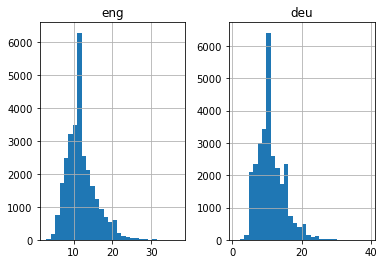

In [5]:
eng_l = []
deu_l = []

for i in df.iloc[:,0]:
  eng_l.append(len(i.split()))

for i in df.iloc[:,1]:
  deu_l.append(len(i.split()))

length_df = pd.DataFrame({'eng':eng_l, 'deu':deu_l})

length_df.hist(bins = 30)
plt.show()

In [6]:
# function to build a tokenizer
def tokenization(lines):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(lines)
    return tokenizer

In [7]:
# prepare english tokenizer
eng_tokenizer = tokenization(df.iloc[:, 0])
eng_vocab_size = len(eng_tokenizer.word_index) + 1

eng_length = 8
print('English Vocabulary Size: %d' % eng_vocab_size)

English Vocabulary Size: 9927


In [8]:
# prepare Deutch tokenizer
deu_tokenizer = tokenization(df.iloc[:, 1])
deu_vocab_size = len(deu_tokenizer.word_index) + 1

deu_length = 8
print('Deutch Vocabulary Size: %d' % deu_vocab_size)

Deutch Vocabulary Size: 18054


In [9]:
def encode_sequences(tokenizer, length, lines):
    seq = tokenizer.texts_to_sequences(lines)
    # pad sequences with 0 values
    seq = pad_sequences(seq, maxlen=length, padding='post')
    return seq

#Model seg2seg

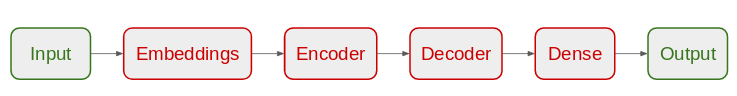

In [17]:
# prepare training data
trainX = encode_sequences(deu_tokenizer, deu_length, df.values[:, 1])
trainY = encode_sequences(eng_tokenizer, eng_length, df.values[:, 0])

In [12]:
# build NMT model
def define_model(in_vocab,out_vocab, in_timesteps,out_timesteps,units):
    model = Sequential()
    model.add(Embedding(in_vocab, units, input_length=in_timesteps, mask_zero=True))
    model.add(Bidirectional(LSTM(units)))
    model.add(RepeatVector(out_timesteps))
    model.add(Bidirectional(LSTM(units, return_sequences=True)))
    model.add(Dense(out_vocab, activation='softmax'))
    return model

In [18]:
# model compilation
model = define_model(deu_vocab_size, eng_vocab_size, deu_length, eng_length, 128)

In [24]:
rms = optimizers.RMSprop(learning_rate=0.001)
model.compile(optimizer=rms, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

callbacks = EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=3)
# train model
history = model.fit(trainX, trainY,
                    epochs=100, batch_size=128, validation_split = 0.2,callbacks=callbacks,
                    verbose=1)

Epoch 1/100
182/182 [==============================] - 95s 452ms/step - loss: 6.4230 - accuracy: 0.1222 - val_loss: 6.1390 - val_accuracy: 0.1139
Epoch 2/100
182/182 [==============================] - 87s 480ms/step - loss: 5.8507 - accuracy: 0.1276 - val_loss: 6.0732 - val_accuracy: 0.1133
Epoch 3/100
182/182 [==============================] - 82s 452ms/step - loss: 5.7672 - accuracy: 0.1285 - val_loss: 6.0143 - val_accuracy: 0.1151
Epoch 4/100
182/182 [==============================] - 80s 442ms/step - loss: 5.7031 - accuracy: 0.1303 - val_loss: 5.9822 - val_accuracy: 0.1163
Epoch 5/100
182/182 [==============================] - 85s 467ms/step - loss: 5.6480 - accuracy: 0.1328 - val_loss: 5.9518 - val_accuracy: 0.1183
Epoch 6/100
182/182 [==============================] - 84s 464ms/step - loss: 5.5780 - accuracy: 0.1349 - val_loss: 5.8755 - val_accuracy: 0.1183
Epoch 7/100
182/182 [==============================] - 85s 468ms/step - loss: 5.4909 - accuracy: 0.1389 - val_loss: 5.8016 -

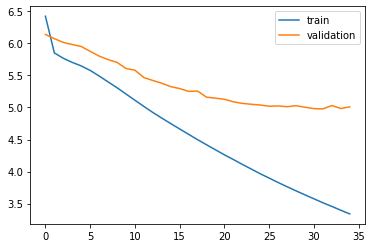

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.show()

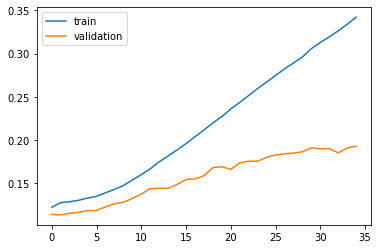

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','validation'])
plt.show()

In [28]:
df_test = pd.read_csv('translation_test.csv')
df_test

,english,german
0,A man in an orange hat starring at something.,"Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt."
1,A Boston Terrier is running on lush green grass in front of a white fence.,Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.
2,A girl in karate uniform breaking a stick with a front kick.,Ein Mädchen in einem Karateanzug bricht einen Stock mit einem Tritt.
3,"Five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.",Fünf Leute in Winterjacken und mit Helmen stehen im Schnee mit Schneemobilen im Hintergrund.
4,People are fixing the roof of a house.,Leute Reparieren das Dach eines Hauses.
...,...,...
995,"Marathon runners are racing on a city street, with other people standing around.",Marathonläufer laufen auf einer städtischen Straße während andere Personen um sie herum stehen.
996,Asian woman wearing a sunhat while riding a bike.,Asiatische Frau trägt einen Sonnenhut beim Fahrradfahren.
997,Some children are outside playing in the dirt where two trees are.,Ein paar Kinder sind im Freien und spielen auf dem Boden bei zwei Bäumen.
998,An older man is playing a video arcade game.,Ein älterer Mann spielt ein Videospiel.


In [29]:
# prepare testing data
testX = encode_sequences(deu_tokenizer, deu_length, df_test.values[:, 1])
testY = encode_sequences(eng_tokenizer, eng_length, df_test.values[:, 0])

In [30]:
preds = model.predict(testX[0].reshape((1,testX.shape[1])))

def get_word(n, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == n:
            return word
    return None

1/1 [==============================] - 2s 2s/step


In [37]:
preds[0]

array([[4.5037343e-09, 7.4408579e-01, 5.1604465e-02, ..., 3.3466455e-07,
        3.4599466e-07, 3.1040270e-07],
       [8.4367244e-08, 3.4213415e-01, 2.6332647e-01, ..., 3.1760047e-07,
        3.5114354e-07, 3.2038156e-07],
       [2.3054180e-07, 5.9681439e-01, 5.1181804e-02, ..., 2.4068191e-07,
        2.6005412e-07, 2.4661617e-07],
       ...,
       [3.6284962e-04, 2.7157643e-03, 9.7479328e-04, ..., 2.1095057e-06,
        1.9459214e-06, 2.0292973e-06],
       [1.9050667e-02, 1.0811243e-02, 2.9376433e-03, ..., 6.8873342e-06,
        6.6639077e-06, 6.7889223e-06],
       [4.0038723e-01, 4.9197435e-05, 9.4142561e-05, ..., 6.9525518e-06,
        7.1769855e-06, 7.8337407e-06]], dtype=float32)

In [35]:
preds_text = []
for i in preds[0]:
  temp = []
  for j in range(len(i)):
      t = get_word(i[j], eng_tokenizer)
      if j > 0:
          if (t == get_word(i[j-1], eng_tokenizer)) or (t == None):
              temp.append('')
          else:
              temp.append(t)
      else:
          if(t == None):
              temp.append('')
          else:
              temp.append(t)

  preds_text.append(' '.join(temp))

In [40]:
preds_text[0]

'                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [35]:
from nltk.translate.bleu_score import sentence_bleu

print('BLEU score -> {}'.format(sentence_bleu(testY, preds_text )))

BLEU score -> 0


#Decoder Beam Search

In [ ]:
!pip install transformers torch sentencepiece

In [ ]:
import torch
from transformers import MarianMTModel, MarianTokenizer

# 1. Tải mô hình và tokenizer 
tokenizer = MarianTokenizer.from_pretrained(model)
model_decode = MarianMTModel.from_pretrained(model)

# 2. Chuẩn bị câu đầu vào
text = "The quick brown fox jumps over the lazy dog."
inputs = tokenizer(text, return_tensors="pt")

# 3. Thực hiện Beam Search
# num_beams: Số lượng "chùm" (ứng cử viên) giữ lại ở mỗi bước
# early_stopping: Dừng lại khi tất cả các luồng beam đều gặp token kết thúc
# num_return_sequences: Số lượng câu dịch muốn lấy ra (phải <= num_beams)
beam_outputs = model_decode.generate(
    inputs["input_ids"], 
    max_length=50, 
    num_beams=5, 
    early_stopping=True,
    num_return_sequences=3 
)

# 4. Giải mã kết quả (Decoder ID -> String)
print(f"Câu gốc: {text}\n")
print("Kết quả Beam Search:")
for i, output in enumerate(beam_outputs):
    decoded_sentence = tokenizer.decode(output, skip_special_tokens=True)
    print(f"{i+1}: {decoded_sentence}")